# Model Building

## Libraries and Modules

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models, datasets

## Preprocessing

In [2]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485,0.456,0.406],
        std = [0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485,0.456,0.406],
        std = [0.229,0.224,0.225]
    )
])

## Datasets

In [3]:
train_dataset = datasets.CIFAR10(
    root = 'data',
    train = True,
    download = True,
    transform = train_transform
)

test_dataset = datasets.CIFAR10(
    root = 'data',
    train = False,
    download = True,
    transform = test_transform
)

train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = 64,
    shuffle = True,
    num_workers = 2
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = 64,
    shuffle = False,
    num_workers = 2
)


100%|██████████| 170M/170M [01:03<00:00, 2.68MB/s]


## Model Backbone

In [4]:
model = models.resnet18(pretrained = True)
for param in model.parameters():
  param.requires_grad = False ## To prevent model weights from being updated

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


#Model Training

## Updating FC layer

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

num_classes = 10

model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

ct = nn.CrossEntropyLoss()
op = torch.optim.Adam(model.fc.parameters(), lr = 0.001)

epochs = 5
for epoch in range(epochs):
  model.train()
  running_loss = 0.0
  for x_batch, y_batch in train_loader:
    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)

    op.zero_grad()
    preds = model(x_batch)
    loss = ct(preds, y_batch)

    if torch.isnan(loss):
      print("Loss is NaN")
      break

    loss.backward()
    op.step()
    running_loss += loss.item()
  print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/5] Loss: 0.8430
Epoch [2/5] Loss: 0.6184
Epoch [3/5] Loss: 0.5883
Epoch [4/5] Loss: 0.5853
Epoch [5/5] Loss: 0.5700


## Updating End layer

In [6]:
for param in model.layer4.parameters():
  param.requires_grad = True

op = torch.optim.Adam(model.parameters(), lr = 1e-4)

for epoch in range(epochs):
  model.train()
  running_loss = 0.0
  for x_batch, y_batch in train_loader:
    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)
    preds = model(x_batch)
    loss = ct(preds, y_batch)
    loss.backward()
    op.step()
    op.zero_grad()

    running_loss += loss.item()

  print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/5] Loss: 0.3879
Epoch [2/5] Loss: 0.1924
Epoch [3/5] Loss: 0.1217
Epoch [4/5] Loss: 0.0778
Epoch [5/5] Loss: 0.0641


In [7]:
torch.save(model.state_dict(), "weights.pth")


# Model Evaluation

## Eval #1

In [8]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
  for x_batch, y_batch in test_loader:
    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)
    preds = model(x_batch)
    _, predicted = torch.max(preds, 1)
    total += y_batch.size(0)
    correct += (predicted == y_batch).sum().item()

  print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 91.42%


Corruption Functions


In [9]:
import torchvision.transforms.functional as F
import random
from PIL import Image, ImageFilter
import io

def gaussian_noise(img, std=0.1):
    tensor = F.to_tensor(img)
    noise = torch.randn_like(tensor) * std
    noisy = torch.clamp(tensor + noise, 0, 1)
    return F.to_pil_image(noisy)

def blur(img, radius=2):
    return img.filter(ImageFilter.GaussianBlur(radius))

def change_brightness(img, factor=0.5):
    return F.adjust_brightness(img, factor)

def jpeg_compress(img, quality=30):
    buffer = io.BytesIO()
    img.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    return Image.open(buffer)

Corrupted Dataset Class

In [10]:
class CorruptedCIFAR10(datasets.CIFAR10):
    def __init__(self, corruption_fn, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.corruption_fn = corruption_fn

    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        img = self.corruption_fn(img)
        return test_transform(img), label


Corrupted datasets

In [11]:
noise_dataset = CorruptedCIFAR10(
    corruption_fn=lambda img: gaussian_noise(img, std=0.2),
    root="data",
    train=False,
    download=True
)
noise_loader = DataLoader(noise_dataset, batch_size=64, shuffle=False)

blur_dataset = CorruptedCIFAR10(
    corruption_fn=lambda img: blur(img, radius=2),
    root="data",
    train=False,
    download=True
)
blur_loader = DataLoader(blur_dataset, batch_size=64, shuffle=False)

brightness_dataset = CorruptedCIFAR10(
    corruption_fn=lambda img: change_brightness(img, factor=0.5),
    root="data",
    train=False,
    download=True
)
brightness_loader = DataLoader(brightness_dataset, batch_size=64, shuffle=False)

compression_dataset = CorruptedCIFAR10(
    corruption_fn=lambda img: jpeg_compress(img, quality=30),
    root="data",
    train=False,
    download = True
)
compression_loader = DataLoader(compression_dataset, batch_size=64, shuffle=False)

## Metrics

In [12]:
def compute_metrics(logits):
  probs = torch.softmax(logits, dim =1)
  confidence,_ = torch.max(probs, dim = 1)
  entropy = -torch.sum(probs * torch.log(probs + 1e-8), dim = 1) ## for avoiding NaN
  return confidence, entropy

## Evaluation under corruption

In [13]:
def eval2(model, loader, entropy_threshold = 1.5):
  model.eval()

  total = 0
  correct = 0
  rejected = 0
  entropy_list = []
  confidence_list = []

  with torch.no_grad():
    for x, y in loader:
      x = x.to(device)
      y = y.to(device)

      logits = model(x)
      conf, ent = compute_metrics(logits)
      preds = logits.argmax(dim = 1)

      total += y.size(0)
      correct += (preds == y).sum().item()

      entropy_list.append(ent.mean().item())
      confidence_list.append(conf.mean().item())
      rejected += (ent > entropy_threshold).sum().item()

  return {
      'accuracy': 100 * correct / total,
      'avg_entropy': sum(entropy_list) / len(entropy_list),
      'avg_confidence': sum(confidence_list) / len(confidence_list),
      'rejection_rate': rejected / total
  }

###Gaussian Noise

In [14]:
gn = eval2(model, noise_loader, entropy_threshold=1.5)
print(gn)

{'accuracy': 12.22, 'avg_entropy': 0.7338837168778584, 'avg_confidence': 0.6880415514775902, 'rejection_rate': 0.0}


### Image blur

In [15]:
ib = eval2(model, blur_loader, entropy_threshold=1.5)
print(ib)

{'accuracy': 18.31, 'avg_entropy': 0.7392766498456336, 'avg_confidence': 0.7290062270346721, 'rejection_rate': 0.0122}


### Brightness Variation

In [16]:
bv = eval2(model, brightness_loader, entropy_threshold=1.5)
print(bv)

{'accuracy': 86.53, 'avg_entropy': 0.19867563670038418, 'avg_confidence': 0.9268936537633277, 'rejection_rate': 0.0028}


### JPEG compression

In [17]:
jc = eval2(model, compression_loader, entropy_threshold=1.5)
print(jc)

{'accuracy': 57.86, 'avg_entropy': 0.49252852702596384, 'avg_confidence': 0.8169258878489208, 'rejection_rate': 0.0175}


Although accuracy is low, avg entropy is low and the confidence is high ->

In [18]:
def softmax_with_temperature(logits, T=2.0):
    return torch.softmax(logits / T, dim=1)

def compute_metrics2(logits, T=2.0):
    probs = softmax_with_temperature(logits, T)
    confidence, _ = torch.max(probs, dim=1)
    entropy = -torch.sum(probs * torch.log(probs + 1e-8), dim=1)
    return confidence, entropy

def eval3(model, loader, entropy_threshold = 1.5):
  model.eval()

  total = 0
  correct = 0
  rejected = 0
  entropy_list = []
  confidence_list = []

  with torch.no_grad():
    for x, y in loader:
      x = x.to(device)
      y = y.to(device)

      logits = model(x)
      conf, ent = compute_metrics2(logits)
      preds = logits.argmax(dim = 1)

      total += y.size(0)
      correct += (preds == y).sum().item()

      entropy_list.append(ent.mean().item())
      confidence_list.append(conf.mean().item())
      rejected += (ent > entropy_threshold).sum().item()

  return {
      'accuracy': 100 * correct / total,
      'avg_entropy': sum(entropy_list) / len(entropy_list),
      'avg_confidence': sum(confidence_list) / len(confidence_list),
      'rejection_rate': rejected / total
  }

# Updated evaluations

gn = eval3(model, noise_loader, entropy_threshold=1.5)
print(gn)

ib = eval3(model, blur_loader, entropy_threshold=1.5)
print(ib)

bv = eval3(model, brightness_loader, entropy_threshold=1.5)
print(bv)

jc = eval3(model, compression_loader, entropy_threshold=1.5)
print(jc)

{'accuracy': 12.68, 'avg_entropy': 1.1576750210136364, 'avg_confidence': 0.5161584813124055, 'rejection_rate': 0.0132}
{'accuracy': 18.31, 'avg_entropy': 1.3489291333848503, 'avg_confidence': 0.5121470046271185, 'rejection_rate': 0.3452}
{'accuracy': 86.53, 'avg_entropy': 0.495546204269312, 'avg_confidence': 0.8360663880208495, 'rejection_rate': 0.0433}
{'accuracy': 57.86, 'avg_entropy': 1.004758107054765, 'avg_confidence': 0.6497206186792653, 'rejection_rate': 0.1933}


#Visualization

## Dataset Image

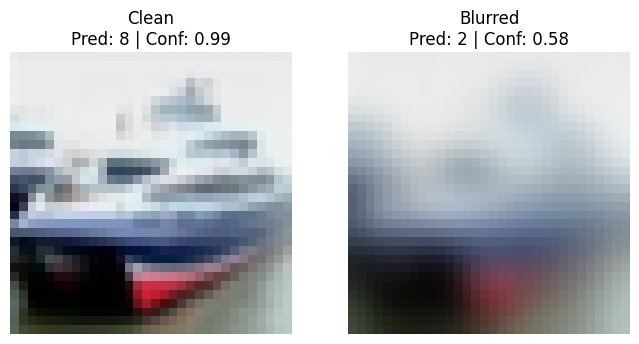

In [19]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F

raw_dataset = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=None
)

img_pil, label = raw_dataset[1]

blurred_img = blur(img_pil, radius=2)

def prepare(img):
    return test_transform(img).unsqueeze(0).to(device)

x_clean = prepare(img_pil)
x_blur = prepare(blurred_img)

model.eval()
with torch.no_grad():
    logits_clean = model(x_clean)
    logits_blur = model(x_blur)

    probs_clean = torch.softmax(logits_clean / 2.0, dim=1)
    probs_blur = torch.softmax(logits_blur / 2.0, dim=1)

    conf_clean, pred_clean = probs_clean.max(dim=1)
    conf_blur, pred_blur = probs_blur.max(dim=1)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].imshow(img_pil)
axs[0].set_title(
    f"Clean\nPred: {pred_clean.item()} | Conf: {conf_clean.item():.2f}"
)
axs[0].axis("off")

axs[1].imshow(blurred_img)
axs[1].set_title(
    f"Blurred\nPred: {pred_blur.item()} | Conf: {conf_blur.item():.2f}"
)
axs[1].axis("off")

plt.show()


## Test Image

{'prediction': 'dog', 'confidence': 0.7367426753044128, 'entropy': 0.6165215969085693, 'decision': 'accepted'}


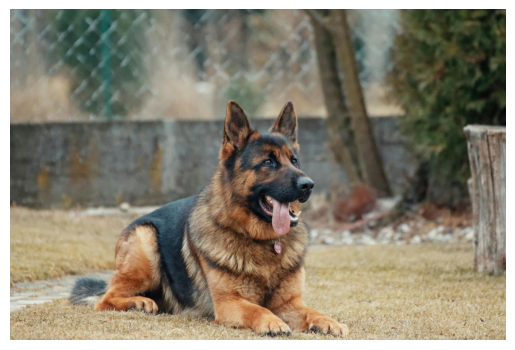

In [22]:
from PIL import Image
import matplotlib.pyplot as plt

CIFAR10_CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

uploaded_img = Image.open("/content/pexels-summerstock-333083.jpg").convert("RGB")
plt.imshow(uploaded_img)
plt.axis("off")

def prepare_image(img):
    return test_transform(img).unsqueeze(0).to(device)

def infer_single_image(model, img, T=2.0, entropy_threshold=1.2):
    model.eval()

    x = prepare_image(img)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits / T, dim=1)

        confidence, pred = probs.max(dim=1)
        entropy = -torch.sum(probs * torch.log(probs + 1e-8), dim=1)

    decision = "accepted"
    if entropy.item() > entropy_threshold:
        decision = "rejected"

    return {
        "prediction": CIFAR10_CLASSES[pred.item()],
        "confidence": confidence.item(),
        "entropy": entropy.item(),
        "decision": decision
    }

result = infer_single_image(model, uploaded_img)
print(result)


In [ ]:
from google.colab import files
files.download("weights.pth")
